In [26]:
# Import necessary libraries for the project
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

# Verify PyTorch installation
print(f"Libraries loaded successfully. PyTorch version: {torch.__version__}")

Libraries loaded successfully. PyTorch version: 2.12.1+cpu


[*********************100%***********************]  1 of 1 completed

Fetching historical data for MSFT...

Data successfully loaded ! Here are the first 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2014-01-02,30.694433,30.892676,30.644872,30.851373,30632200
2014-01-03,30.487936,30.743999,30.231873,30.727479,31134800
2014-01-06,29.843662,30.471427,29.827142,30.438386,43603700
2014-01-07,30.074930,30.141012,29.909728,30.008851,35802800
2014-01-08,29.538023,29.851907,29.389345,29.736266,59971700


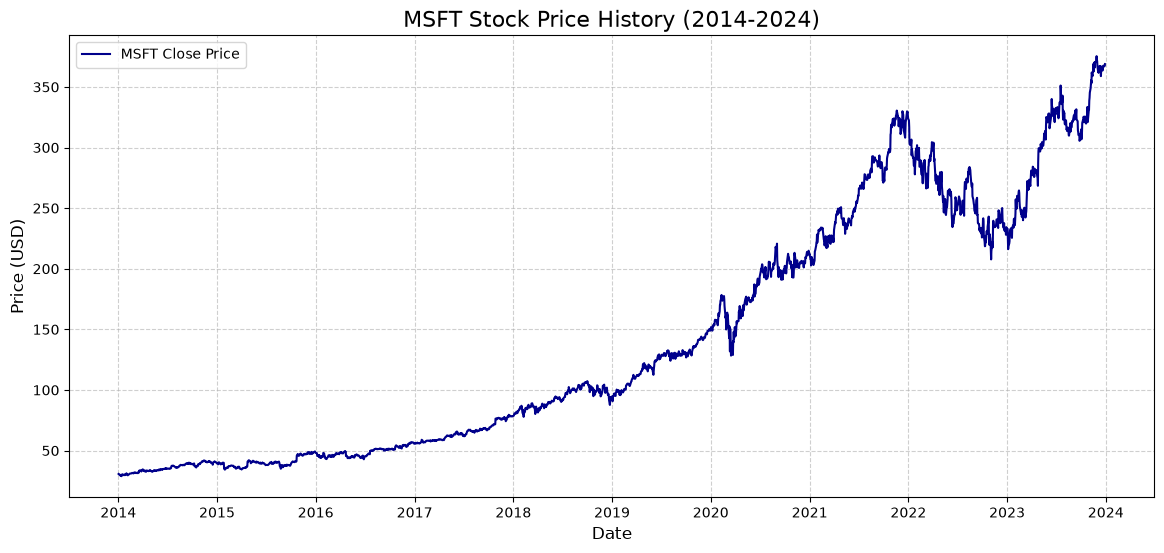

In [27]:
# 1. Define the stock ticker and the time range
ticker = 'MSFT'


start_date = '2014-01-01'
end_date = '2024-01-01'

# 2. Download the data using yfinance API
print(f"Fetching historical data for {ticker}...")
data = yf.download(ticker, start = start_date, end = end_date)

# 3. View the structure of our data
print("\nData successfully loaded ! Here are the first 5 rows:"),
# display() : html format / a table
display(data.head()) 

# 4. Visualize the 'Close' price to understand the historical trend
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label=f'{ticker} Close Price', color ='darkblue')

plt.title(f"{ticker} Stock Price History (2014-2024)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



In [28]:
# 1. Extract only the 'Close' column and convert it to a 2D NumPy array
prices = data[['Close']].values

# 2. Initialize the scaler to compress data between -1 and 1

scaler = MinMaxScaler(feature_range=(-1,1))

scaled_data = scaler.fit_transform(prices)

# 4. Verify the scaling process

print("--- Scaling Process Successful! ---")
print(f"Original Minimum Price: {prices.min():.2f} USD | Original Maximum Price:{prices.max():.2f} USD")
print(f"Scaled Min Value: {scaled_data.min():.2f} | Scaled Max Value: {scaled_data.max():.2f}\n")

print("First 5 days of scaled data:")
print(scaled_data[:5])

--- Scaling Process Successful! ---
Original Minimum Price: 28.89 USD | Original Maximum Price:375.41 USD
Scaled Min Value: -1.00 | Scaled Max Value: 1.00

First 5 days of scaled data:
[[-0.98960677]
 [-0.99079863]
 [-0.99451725]
 [-0.99318242]
 [-0.99628134]]


In [29]:
import numpy as np

def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        window = data[i:(i + window_size)]
        target = data[i + window_size]

        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

WINDOW_SIZE = 20
X, y = create_sequences(scaled_data, WINDOW_SIZE)

print("--- Sequence Creation Successful! ---")
print(f"Total sequences created: {len(X)}")
print(f"Shape of X (Inputs): {X.shape} -> (Total Samples, Window Size, Features)")
print(f"Shape of y (Targets): {y.shape} -> (Total Samples, Features)")

--- Sequence Creation Successful! ---
Total sequences created: 2496
Shape of X (Inputs): (2496, 20, 1) -> (Total Samples, Window Size, Features)
Shape of y (Targets): (2496, 1) -> (Total Samples, Features)


In [30]:
# 1. Find the index that splits the data at %80
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

# 2. Split the data chronologically

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

# 3. Verify the split
print("--- Train/Test Split Successful! ---")
print(f"Training sequences (X_train): {len(X_train)}")
print(f"Testing sequences (X_test): {len(X_test)}")

--- Train/Test Split Successful! ---
Training sequences (X_train): 1996
Testing sequences (X_test): 500


In [31]:
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32)

X_test_tensor = torch.tensor(X_test, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32)

# Verify the shape and data type of the created tensors
print("--- Tensor Conversion Successful! ---")
print(f"X_train Tensor Shape: {X_train_tensor.shape} | Data Type: {X_train_tensor.dtype}")
print(f"y_train Tensor Shape: {y_train_tensor.shape} | Data Type: {y_train_tensor.dtype}")
print(f"X_test Tensor Shape: {X_test_tensor.shape} | Data Type: {X_test_tensor.dtype}")
print(f"y_test Tensor Shape: {y_test_tensor.shape} | Data Type: {y_test_tensor.dtype}")

--- Tensor Conversion Successful! ---
X_train Tensor Shape: torch.Size([1996, 20, 1]) | Data Type: torch.float32
y_train Tensor Shape: torch.Size([1996, 1]) | Data Type: torch.float32
X_test Tensor Shape: torch.Size([500, 20, 1]) | Data Type: torch.float32
y_test Tensor Shape: torch.Size([500, 1]) | Data Type: torch.float32


In [ ]:
# 1. Define the LSTM Model Architecture

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__() # Inherit from PyTorch base module

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        self.fc= nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        out = self.fc(out[:, -1, :])

        return out

print("--- Model Initialization ---")
model_lstm = LSTMModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
print(model_lstm)
    



--- Model Initialization ---
LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [9]:
# 1. Define the Loss Function

criterion = nn.MSELoss()



# 2. Define the Optimizer

# learnin rate = 0.001

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)



# 3. Verify initialization

print("--- Loss Function and Optimizer Initialized! ---")

print(f"Loss Function: {criterion}")

print(f"Optimizer: {optimizer.__class__.__name__} with Learning Rate: 0.001")

--- Loss Function and Optimizer Initialized! ---
Loss Function: MSELoss()
Optimizer: Adam with Learning Rate: 0.001


In [10]:
# 1. Define the number of epochs (How many times the model will see the entire training daata)
num_epochs = 100

print("--- Training Started ---")

for epoch in range(num_epochs):
    # Set the model to training mode
    model_lstm.train()

    # STEP 1: Forward Pass
    # The model tries to predict the prices based on the training data
    outputs = model_lstm(X_train_tensor)

    # STEP 2: Calculate Loss
    # The 'exam grader' compares predictions to the actual answers
    loss = criterion(outputs, y_train_tensor)

    # STEP 3: Zero Gradients
    # Clear the old gradients from the previous step so they do not mix up
    optimizer.zero_grad()

    # STEP 4: Backward Pass
    # Calculate how much each 'neuron' contributed to the error
    loss.backward()

    # STEP 5: Optimize
    # The 'coach' updates the model's internal weights to improve next time
    optimizer.step()

    # Print the progress every 10 epochs to monitor the learning

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1} / {num_epochs}], Loss: {loss.item():.6f}')

print("--- Training Finished! ---")

--- Training Started ---
Epoch [10 / 100], Loss: 0.343326
Epoch [20 / 100], Loss: 0.215466
Epoch [30 / 100], Loss: 0.173204
Epoch [40 / 100], Loss: 0.130687
Epoch [50 / 100], Loss: 0.085875
Epoch [60 / 100], Loss: 0.048559
Epoch [70 / 100], Loss: 0.032773
Epoch [80 / 100], Loss: 0.025017
Epoch [90 / 100], Loss: 0.016076
Epoch [100 / 100], Loss: 0.009074
--- Training Finished! ---


In [13]:
# Set the model to evaluation mode
model_lstm.eval()

# Disable gradient calculation to save memory and computation during inference
with torch.no_grad():
    # Get predictions for both training and testing data
    train_predictions = model_lstm(X_train_tensor).numpy()
    test_predictions = model_lstm(X_test_tensor).numpy()

# Inverse transform the predictions and actuals from [-1, 1] back to original USD values
train_predictions_usd = scaler.inverse_transform(train_predictions)
y_train_usd = scaler.inverse_transform(y_train_tensor.numpy())

test_predictions_usd = scaler.inverse_transform(test_predictions)
y_test_usd = scaler.inverse_transform(y_test_tensor.numpy())

# Verify the predictions
print("--- Predictions Completed! ---")
print(f"First Test Day Actual Price: {y_test_usd[0][0]:.2f} USD")
print(f"First Test Day Predicted Price: {test_predictions_usd[0][0]:.2f} USD")

--- Predictions Completed! ---
First Test Day Actual Price: 316.93 USD
First Test Day Predicted Price: 247.43 USD


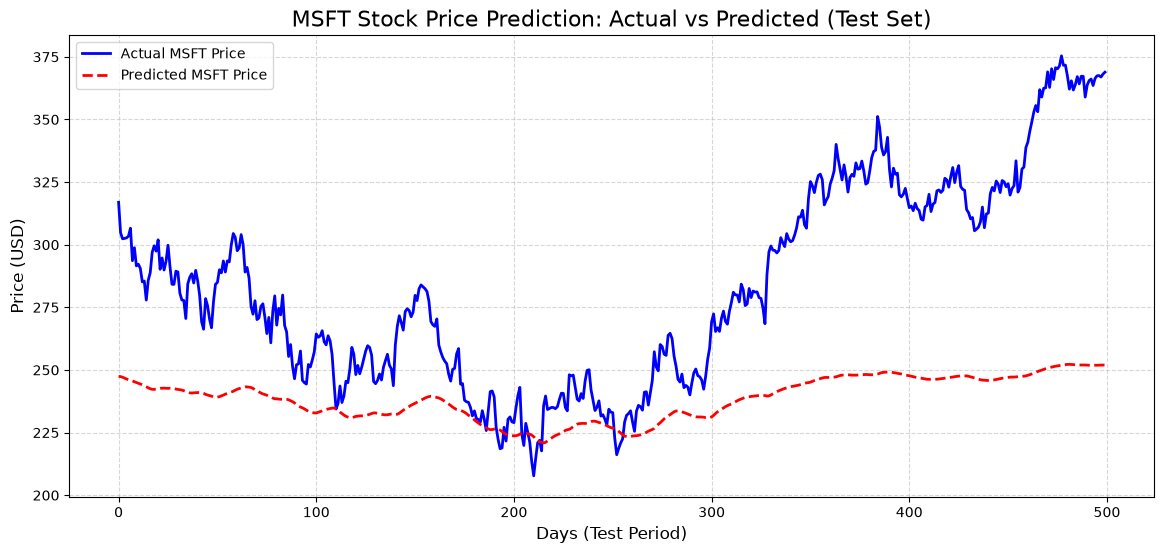

In [19]:
import matplotlib.pyplot as plt

# Plotting the Actual vs Predicted Prices for the Test Set
plt.figure(figsize=(14, 6))

# Plot the real prices in blue
plt.plot(y_test_usd, color = 'blue', label = 'Actual MSFT Price', linewidth=2)

# Plot the model's predictions in red
plt.plot(test_predictions_usd, color = 'red', label = 'Predicted MSFT Price', linestyle='dashed', linewidth=2)

# Professional formatting
plt.title('MSFT Stock Price Prediction: Actual vs Predicted (Test Set)', fontsize = 16)
plt.xlabel('Days (Test Period)', fontsize=12)
plt.ylabel('Price (USD)', fontsize = 12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
